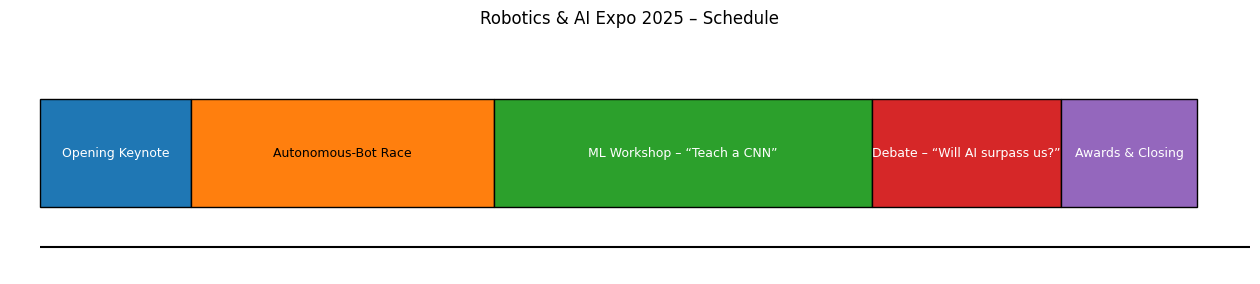

In [10]:
# This code was designed for the animation, since I didn't want to spend too much time doing it in Blender, I decided a quick Matplotlib would do it.

import matplotlib.pyplot as plt
import matplotlib.animation as anim
from matplotlib.patches import Rectangle
from IPython.display import HTML
import numpy as np
from matplotlib.animation import FFMpegWriter
import matplotlib as mpl
import os
import imageio_ffmpeg

# --- DATA ---
events = [
    ("Opening Keynote",               10.00, 11.00),
    ("Autonomous-Bot Race",          11.00, 13.00),
    ("ML Workshop – “Teach a CNN”",  13.00, 15.50),
    ("Debate – “Will AI surpass us?”",15.50, 16.75),
    ("Awards & Closing",              16.75, 17.00),
]

# make sure the folder exists
out_dir = r'C:\Users\iHunter\OneDrive\Desktop\Building-U\bu-learning\Exercise 2\media'
os.makedirs(out_dir, exist_ok=True)
out_path = os.path.join(out_dir, 'robotics_schedule.mp4')

# --- FIGURE SETUP ---
fig, ax = plt.subplots(figsize=(16, 2.8))
mpl.rcParams['animation.ffmpeg_path'] = imageio_ffmpeg.get_ffmpeg_exe()

# hide everything (axes, ticks, spines)
ax.axis('off')


# Let's assume 1 hour between each event
margin = 1.0
ax.set_xlim(9.8, events[-1][2] + margin)
ax.set_ylim(-0.05, 0.75)

# horizontal baseline
ax.hlines(0.05, events[0][1], events[-1][2] + margin, lw=1.5, color="k")

ax.set_title("Robotics & AI Expo 2025 – Schedule", pad=25)

# color palette + contrast helper
palette = plt.get_cmap("tab10").colors


def best_text_colour(rgb):
    r, g, b = rgb
    return "black" if 0.2126*r + 0.7152*g + 0.0722*b > 0.55 else "white"

# Set minimum bar width (for display purposes)
MIN_BAR_WIDTH = 0.9

bars, labels, grads = [], [], [None]*len(events)

# initial patch + text creation (width=0 to animate in)
for i, (lab, start, end) in enumerate(events):
    real_w   = end - start
    disp_w   = max(real_w, MIN_BAR_WIDTH)   # enforce minimum for display
    color    = palette[i % len(palette)]
    y0, h    = 0.20, 0.40

    # bar (starts at zero, grows to disp_w)
    rect = Rectangle((start, y0), 0, h, color=color, ec="none", zorder=1)
    ax.add_patch(rect)
    bars.append((rect, real_w, disp_w))

    # label (alpha=0 at start)
    txt = ax.text(start, y0 + h/2, lab,
                  ha="left", va="center",
                  fontsize=9, alpha=0.0,
                  color=best_text_colour(color),
                  zorder=2)
    labels.append(txt)

# gradient helper function
def make_gradient(ax, x0, w, col, y0=0.20, h=0.40, n=120):
    try:
        grad = np.linspace(0,1,n)[:,None] * np.array(col)
        im   = ax.imshow(grad[None,:,:],
                         extent=[x0, x0+w, y0, y0+h],
                         aspect="auto", zorder=0.5)
        im.set_clip_path(Rectangle((x0, y0), w, h, transform=ax.transData))
        return im
    except:
        return None

# --- ANIMATION LOGIC ---
fps              = 25
frames_per_event = 40
pause_frames     = 10
total_frames     = len(events) * (frames_per_event + pause_frames)

def animate(frame):
    idx, local = divmod(frame, frames_per_event + pause_frames)
    artists = []

    for i, ((rect, real_w, disp_w), txt) in enumerate(zip(bars, labels)):
        s = events[i][1]
        # Past events → full width
        if i < idx:
            rect.set_x(s)
            rect.set_width(disp_w)
            rect.set_edgecolor("k")
            txt.set_alpha(1.0)

        # Current event sliding in
        elif i == idx and local < frames_per_event:
            p = local / frames_per_event
            rect.set_x(s)
            rect.set_width(disp_w * p)
            # if the _real_ bar is tall enough, fade in text; otherwise show full alpha
            if real_w >= MIN_BAR_WIDTH:
                txt.set_alpha(p)
            else:
                txt.set_alpha(1.0)

        # Landed/current-pause (blink outline)
        elif i == idx:
            rect.set_x(s)
            rect.set_width(disp_w)
            rect.set_edgecolor("k" if (local - frames_per_event) % 2 else "none")
            txt.set_alpha(1.0)

        # Future events → hidden
        else:
            rect.set_width(0)
            txt.set_alpha(0.0)

        # label placement (center if wide, outside if skinny)
        if disp_w >= MIN_BAR_WIDTH:
            txt.set_x(s + disp_w/2)
            txt.set_ha("center")
        else:
            txt.set_x(s + disp_w + 0.05)
            txt.set_ha("left")

        artists += [rect, txt]

    return artists

ani = anim.FuncAnimation(fig, animate,
                         frames=total_frames,
                         interval=1000/fps,
                         blit=True)

# Display in Jupyter/VS Code interactive window
HTML(ani.to_jshtml())
# save to media/ folder (make sure it exists!)

# --- ANIMATION SAVE ---
# set up the writer
writer = FFMpegWriter(
    fps=fps,
    codec='libx264',
    bitrate=1800,
    extra_args=['-pix_fmt', 'yuv420p']
)

# save the file
ani.save(out_path, writer=writer)